In [1]:
import os
import sys
from pathlib import Path

# Resolve repository root and set working directory
root = Path.cwd().resolve()
while root != root.parent:
    if (root / 'src').exists() and (root / 'config').exists():
        break
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))
os.chdir(root)
print(f"Working directory: {root}")


Working directory: C:\Users\given\Downloads\dozer-predictive-maintenance\dozer_predictive_maintenance


# 03. Target Definition, Leakage Prevention & Feature Importance

Formulation of the 24-hour event-centred early warning target, class imbalance characterization, multi-machine leakage prevention, and Random Forest feature importance selection.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from src.data.load_data import load_workbook
from src.targets.build_target import add_failure_target
from src.utils.io import load_config

sns.set_theme(style="whitegrid")
config = load_config()
workbook = load_workbook(config["project"]["raw_file"])
telemetry = workbook["telemetry"]
events = workbook["events"]


## 1. Multi-Horizon Early Warning Target Comparison


   Horizon (Hours)  Positive Hours  Total Hours  Positive Class (%)
0                6              12         6602            0.181763
1               12              24         6602            0.363526
2               24              48         6602            0.727052
3               48              96         6602            1.454105
4               72             144         6602            2.181157


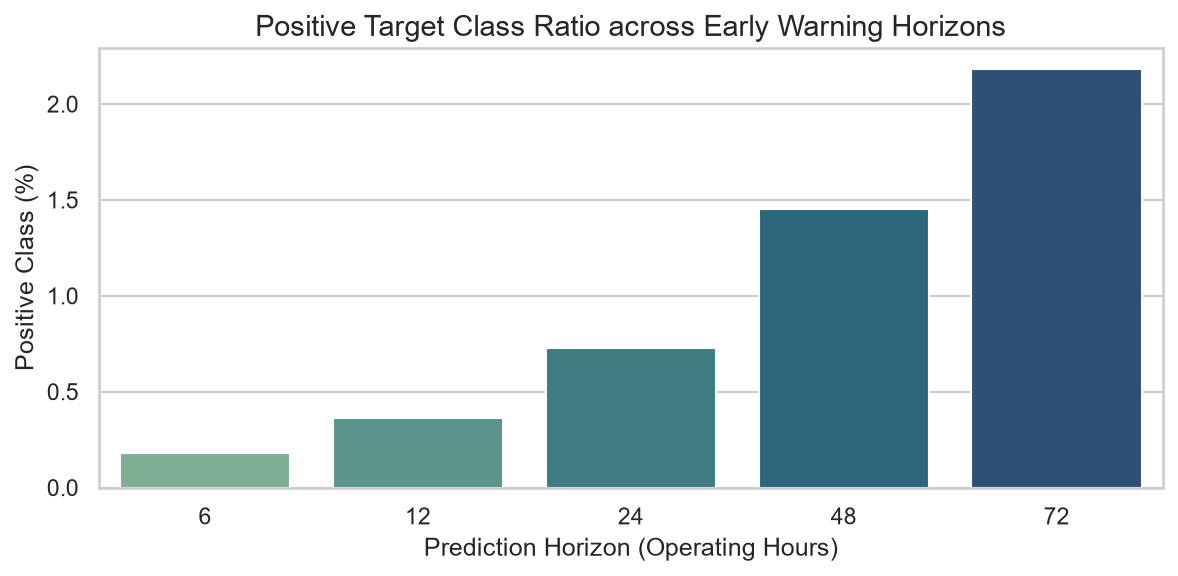

In [3]:
horizons = [6, 12, 24, 48, 72]
summary = []

for h in horizons:
    df_h = add_failure_target(telemetry, events, horizon_operating_hours=h)
    pos = int(df_h["target_failure"].sum())
    total = len(df_h)
    summary.append({
        "Horizon (Hours)": h,
        "Positive Hours": pos,
        "Total Hours": total,
        "Positive Class (%)": (pos / total) * 100
    })

horizon_df = pd.DataFrame(summary)
display(horizon_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=horizon_df, x="Horizon (Hours)", y="Positive Class (%)", palette="crest")
plt.title("Positive Target Class Ratio across Early Warning Horizons", fontsize=14)
plt.ylabel("Positive Class (%)")
plt.xlabel("Prediction Horizon (Operating Hours)")
plt.tight_layout()
plt.show()


## 2. 24-Hour Target Class Imbalance Breakdown


Target Class Counts:
target_failure
0    6554
1      48
Name: count, dtype: int64


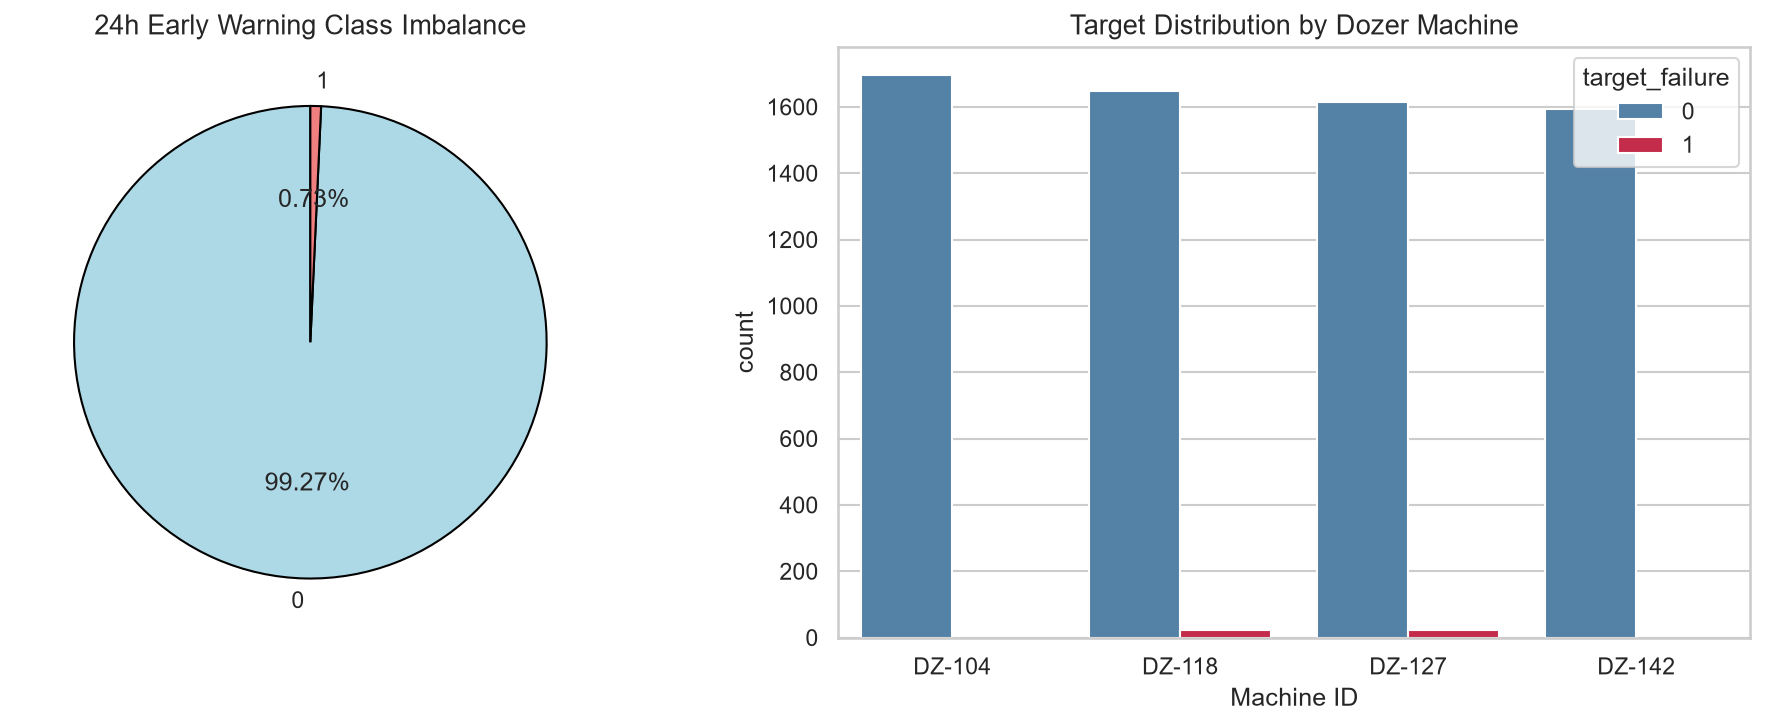

In [4]:
df_target = add_failure_target(telemetry, events, horizon_operating_hours=24)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
df_target["target_failure"].value_counts().plot.pie(
    autopct="%1.2f%%", colors=["lightblue", "lightcoral"], ax=ax1, startangle=90, wedgeprops={"edgecolor": "black"}
)
ax1.set_title("24h Early Warning Class Imbalance", fontsize=13)
ax1.set_ylabel("")

sns.countplot(data=df_target, x="Machine ID", hue="target_failure", palette=["steelblue", "crimson"], ax=ax2)
ax2.set_title("Target Distribution by Dozer Machine", fontsize=13)
plt.tight_layout()
plt.show()

print("Target Class Counts:")
print(df_target["target_failure"].value_counts())


## 3. Degradation Feature Importance Ranking


Top 15 Most Discriminative Features:
TM Main Press Max__roll_std_24        0.051846
TC Oil Temp Max__roll_mean_72         0.039718
RB Rear Exh Temp__roll_mean_72        0.037317
Blow-by Press Max__roll_std_72        0.035196
Front Pump Press Max__roll_mean_72    0.035079
Oil Temp Max__warning_count_24        0.033581
Oil Temp Max__roll_mean_24            0.031058
SMR                                   0.024924
Rear Pump Press Max__roll_mean_72     0.024602
RB Front Exh Temp__roll_std_72        0.024086
LB Front Exh Temp__roll_std_72        0.023372
Hyd Oil Temp Max__warning_count_72    0.021870
Blow-by Press Max__roll_std_24        0.019843
Engine Speed Avg__roll_std_24         0.019043
RB Rear Exh Temp__warning_count_24    0.018698
dtype: float64


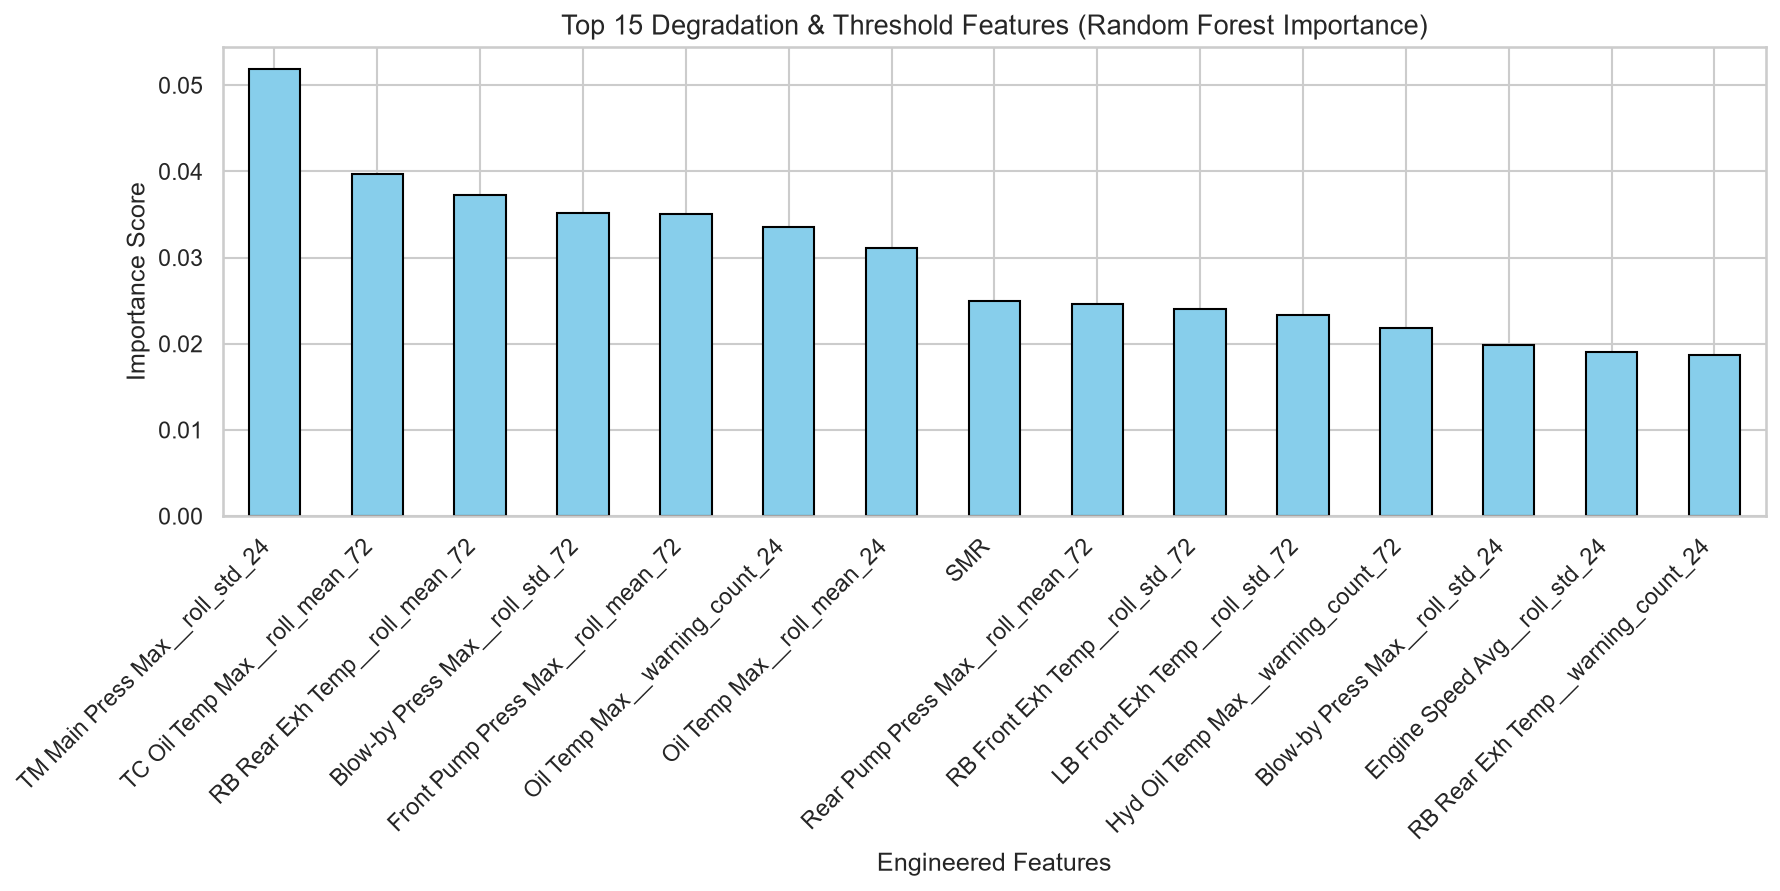

In [5]:
df_features = pd.read_csv(config["project"]["featured_file"], parse_dates=["Timestamp"])
X = df_features.select_dtypes(include=np.number).drop(columns=["target_failure"], errors="ignore")
y = df_features["target_failure"].astype(int)

X_clean = X.fillna(X.median())

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_clean, y)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 15 Most Discriminative Features:")
print(feat_imp.head(15))

plt.figure(figsize=(12, 6))
feat_imp.head(15).plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 15 Degradation & Threshold Features (Random Forest Importance)", fontsize=13)
plt.ylabel("Importance Score")
plt.xlabel("Engineered Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
